In [1]:
import pandas as pd
import seaborn as sns
import pingouin as pg

/opt/conda/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


❓ Вопрос: 
Зависит ли длина чашелистика от вида ириса?

In [3]:
data = pd.read_csv('csv_data/Iris.csv', index_col='Id')

In [4]:
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica


In [5]:
data.groupby('Species')['SepalLengthCm'].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,5.006,0.352490,4.3,4.800,5.0,5.2,5.8
Iris-versicolor,50.0,5.936,0.516171,4.9,5.600,5.9,6.3,7.0
Iris-virginica,50.0,6.588,0.635880,4.9,6.225,6.5,6.9,7.9


In [7]:
print(pg.normality(data[data.Species == "Iris-setosa"].SepalLengthCm))
print(pg.normality(data[data.Species == "Iris-virginica"].SepalLengthCm))
print(pg.normality(data[data.Species == "Iris-versicolor"].SepalLengthCm))
# Распределение длин лепестков у каждого вида - нормальное


                      W      pval  normal
SepalLengthCm  0.977699  0.459513    True
                      W      pval  normal
SepalLengthCm  0.971179  0.258315    True
                      W      pval  normal
SepalLengthCm  0.977836  0.464737    True


In [8]:
pg.homoscedasticity(data=data, dv='SepalLengthCm', group='Species', method='levene')
# Дисперсии не равны

,W,pval,equal_var
levene,6.35272,0.002259,False


In [10]:
pg.welch_anova(
    dv="SepalLengthCm", 
    between="Species", 
    data=data
)

# Так как распределение нормальные, но диспресии не равны - используем Welch Anova. Он параметрический,
# не требует гомогенности дисперсий. 
# Видим наличие значимого различия, проверяем попарно.

,Source,ddof1,ddof2,F,p-unc,np2
0,Species,2,92.211145,138.908285,1.505059e-28,0.618706


In [12]:
pg.pairwise_tests(
    data,
    dv='SepalLengthCm',
    between='Species',
    padjust='fdr_bh', # вот это поправка на множественные сравнения
    correction=True   # вот это включает Уэлча, чтобы не переживать за неравные дисперсии
)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,Species,Iris-setosa,Iris-versicolor,False,True,-10.520986,86.538002,two-sided,3.746743e-17,5.620114e-17,fdr_bh,4.19e+14,-2.088053
1,Species,Iris-setosa,Iris-virginica,False,True,-15.386196,76.515867,two-sided,3.966867e-25,1.190060e-24,fdr_bh,2.948e+24,-3.053629
2,Species,Iris-versicolor,Iris-virginica,False,True,-5.629165,94.025486,two-sided,1.866144e-07,1.866144e-07,fdr_bh,7.037e+04,-1.117195


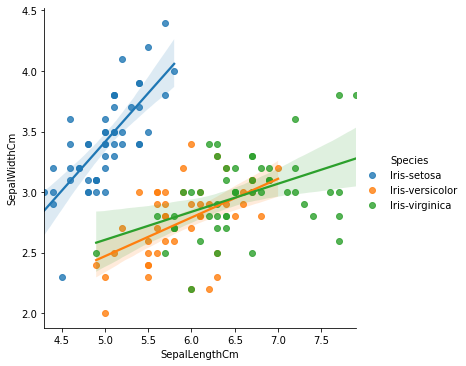

In [13]:
sns.lmplot(data=data, x="SepalLengthCm", y="SepalWidthCm", hue='Species')

### Вывод
Длина лепестков у каждого вида действительно значимо отличается с p-corr < 0.05. Также, если посмотреть на точченый график размера (ширину и длину) лепестков каждого вида, также невооруженным глазом различие. Средняя длина чашелистика статистически значимо различается между видами ириса. Попарные сравнения показали значимые различия между всеми тремя видами.